In [8]:
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
pd.set_option(
    "display.max_columns",
    None
)

print("Comparison environment ready.")

Comparison environment ready.


In [10]:
result = subprocess.run(
    [
        "kaggle",
        "kernels",
        "list",
        "--user",
        "thegreatsage",
        "--page-size",
        "100"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

ref                                                       title                                            author          lastRunTime                 totalVotes  
--------------------------------------------------------  -----------------------------------------------  --------------  --------------------------  ----------  
thegreatsage/10-xception                                  10-xception                                      The Great sage  2026-08-24 16:49:51.787000           0  
thegreatsage/02-resnet50-cross-validation                 02_resnet50_cross_validation                     The Great sage  2026-08-24 09:48:14.043000           2  
thegreatsage/09-mobilenetv2-cross-validation              09-mobilenetv2-cross-validation                  The Great sage  2026-08-24 16:20:56.933000           0  
thegreatsage/08-mobilenetv2                               08-mobilenetv2                                   The Great sage  2026-08-24 14:59:38.640000           0  
thegreatsage/07-

In [11]:
import kagglehub
from pathlib import Path

saved_notebooks = {
    "DenseNet121 CV": (
        "thegreatsage/05-densenet121-crossvalidation",
        "densenet121_cv_test_results.csv"
    ),

    "EfficientNetB0": (
        "thegreatsage/06-efficientnetb0",
        "efficientnetb0_results.csv"
    ),

    "EfficientNetB0 CV": (
        "thegreatsage/07-efficientnetb0-cross-validation",
        "efficientnetb0_cv_test_results.csv"
    ),

    "MobileNetV2": (
        "thegreatsage/08-mobilenetv2",
        "mobilenetv2_results.csv"
    ),

    "MobileNetV2 CV": (
        "thegreatsage/09-mobilenetv2-cross-validation",
        "mobilenetv2_cv_test_results.csv"
    ),

    "Xception": (
        "thegreatsage/10-xception",
        "xception_results.csv"
    ),

    "Xception CV": (
        "thegreatsage/11-xception-cross-validation",
        "xception_cv_test_results.csv"
    )
}

downloaded_files = {}

for experiment, (handle, filename) in saved_notebooks.items():
    try:
        file_path = kagglehub.notebook_output_download(
            handle,
            path=filename
        )

        downloaded_files[experiment] = Path(
            file_path
        )

        print(
            "SUCCESS:",
            experiment,
            "->",
            file_path
        )

    except Exception as error:
        print(
            "FAILED:",
            experiment,
            "->",
            error
        )

FAILED: DenseNet121 CV -> 'densenet121_cv_test_results.csv' is not present in the notebook output files.You can access the other files of the attached notebook at '/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation'
FAILED: EfficientNetB0 -> 'efficientnetb0_results.csv' is not present in the notebook output files.You can access the other files of the attached notebook at '/kaggle/input/notebooks/thegreatsage/06-efficientnetb0'
FAILED: EfficientNetB0 CV -> 'efficientnetb0_cv_test_results.csv' is not present in the notebook output files.You can access the other files of the attached notebook at '/kaggle/input/notebooks/thegreatsage/07-efficientnetb0-cross-validation'
FAILED: MobileNetV2 -> 'mobilenetv2_results.csv' is not present in the notebook output files.You can access the other files of the attached notebook at '/kaggle/input/notebooks/thegreatsage/08-mobilenetv2'
FAILED: MobileNetV2 CV -> 'mobilenetv2_cv_test_results.csv' is not present in the notebook output files

In [12]:
notebook_mounts = {
    "DenseNet121 CV":
        "/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation",

    "EfficientNetB0":
        "/kaggle/input/notebooks/thegreatsage/06-efficientnetb0",

    "EfficientNetB0 CV":
        "/kaggle/input/notebooks/thegreatsage/07-efficientnetb0-cross-validation",

    "MobileNetV2":
        "/kaggle/input/notebooks/thegreatsage/08-mobilenetv2",

    "MobileNetV2 CV":
        "/kaggle/input/notebooks/thegreatsage/09-mobilenetv2-cross-validation",

    "Xception":
        "/kaggle/input/notebooks/thegreatsage/10-xception",

    "Xception CV":
        "/kaggle/input/notebooks/thegreatsage/11-xception-cross-validation"
}

for experiment, folder in notebook_mounts.items():
    folder_path = Path(folder)

    files = [
        file
        for file in folder_path.rglob("*")
        if file.is_file()
    ]

    print(f"\n--- {experiment} ---")

    if files:
        for file in files:
            print(file)
    else:
        print("No saved output files")


--- DenseNet121 CV ---
/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation/__results__.html
/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation/__notebook__.ipynb
/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation/__output__.json
/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation/custom.css
/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation/__results___files/__results___15_0.png
/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation/__results___files/__results___20_0.png
/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation/__results___files/__results___19_0.png
/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation/__results___files/__results___16_0.png
/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation/__results___files/__results___17_0.png
/kaggle/input/notebooks/thegreatsage/05-densenet121-crossvalidation/__results___files/__results___18_0.png

In [13]:
import json
import re

def read_saved_outputs(notebook_path):
    with open(
        notebook_path,
        "r",
        encoding="utf-8"
    ) as file:
        notebook = json.load(file)

    collected_text = []

    for cell in notebook.get("cells", []):
        for output in cell.get("outputs", []):
            text = output.get("text", [])

            if isinstance(text, str):
                collected_text.append(text)
            else:
                collected_text.extend(text)

            plain_text = output.get(
                "data", {}
            ).get("text/plain", [])

            if isinstance(plain_text, str):
                collected_text.append(plain_text)
            else:
                collected_text.extend(plain_text)

    return "\n".join(collected_text)


def find_metric(text, names):
    for name in names:
        matches = re.findall(
            rf"{re.escape(name)}\s*:\s*([0-9.]+)",
            text
        )

        if matches:
            return float(matches[-1])

    return np.nan


automatic_experiments = {
    "DenseNet121 + 5-Fold CV": {
        "folder": notebook_mounts["DenseNet121 CV"],
        "model": "DenseNet121",
        "cv": "5-Fold"
    },

    "EfficientNetB0": {
        "folder": notebook_mounts["EfficientNetB0"],
        "model": "EfficientNetB0",
        "cv": "No"
    },

    "EfficientNetB0 + 5-Fold CV": {
        "folder": notebook_mounts["EfficientNetB0 CV"],
        "model": "EfficientNetB0",
        "cv": "5-Fold"
    },

    "MobileNetV2": {
        "folder": notebook_mounts["MobileNetV2"],
        "model": "MobileNetV2",
        "cv": "No"
    },

    "MobileNetV2 + 5-Fold CV": {
        "folder": notebook_mounts["MobileNetV2 CV"],
        "model": "MobileNetV2",
        "cv": "5-Fold"
    },

    "Xception": {
        "folder": notebook_mounts["Xception"],
        "model": "Xception",
        "cv": "No"
    },

    "Xception + 5-Fold CV": {
        "folder": notebook_mounts["Xception CV"],
        "model": "Xception",
        "cv": "5-Fold"
    }
}

automatic_rows = []

for experiment, information in automatic_experiments.items():
    notebook_path = (
        Path(information["folder"])
        / "__notebook__.ipynb"
    )

    output_text = read_saved_outputs(
        notebook_path
    )

    row = {
        "Experiment": experiment,
        "Model": information["model"],
        "Cross-Validation": information["cv"],

        "Test Loss": find_metric(
            output_text,
            ["Test Loss", "Test loss"]
        ),

        "Accuracy": find_metric(
            output_text,
            ["Test Accuracy", "Accuracy"]
        ),

        "Precision": find_metric(
            output_text,
            ["Precision"]
        ),

        "Recall": find_metric(
            output_text,
            ["Recall"]
        ),

        "F1-score": find_metric(
            output_text,
            ["F1-score"]
        ),

        "ROC-AUC": find_metric(
            output_text,
            ["ROC-AUC"]
        )
    }

    automatic_rows.append(row)

automatic_results_df = pd.DataFrame(
    automatic_rows
)

display(
    automatic_results_df.round(4)
)

,Experiment,Model,Cross-Validation,Test Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,DenseNet121 + 5-Fold CV,DenseNet121,5-Fold,0.5575,0.7217,0.9046,0.6791,0.7758,0.8431
1,EfficientNetB0,EfficientNetB0,No,0.5603,0.7530,0.8447,0.7985,0.8210,0.7824
2,EfficientNetB0 + 5-Fold CV,EfficientNetB0,5-Fold,0.5477,0.7395,0.8945,0.7173,0.7962,0.8316
3,MobileNetV2,MobileNetV2,No,0.5837,0.6977,0.9271,0.6226,0.7450,0.8531
4,MobileNetV2 + 5-Fold CV,MobileNetV2,5-Fold,0.5486,0.7235,0.9158,0.6718,0.7751,0.8528
5,Xception,Xception,No,0.5520,0.7242,0.9042,0.6835,0.7785,0.8374
6,Xception + 5-Fold CV,Xception,5-Fold,0.5497,0.7317,0.8863,0.7130,0.7903,0.8286


In [14]:
manual_results_df = pd.DataFrame([
    {
        "Experiment": "ResNet50",
        "Model": "ResNet50",
        "Cross-Validation": "No",
        "Test Loss": 0.5060,
        "Accuracy": 0.7555,
        "Precision": 0.9148,
        "Recall": 0.7224,
        "F1-score": 0.8073,
        "ROC-AUC": 0.8651
    },

    {
        "Experiment": "ResNet50 + 5-Fold CV",
        "Model": "ResNet50",
        "Cross-Validation": "5-Fold",
        "Test Loss": 0.5062,
        "Accuracy": 0.7545,
        "Precision": 0.9144,
        "Recall": 0.7214,
        "F1-score": 0.8065,
        "ROC-AUC": 0.8658
    },

    {
        "Experiment": "DenseNet121",
        "Model": "DenseNet121",
        "Cross-Validation": "No",
        "Test Loss": 0.5596,
        "Accuracy": 0.7214,
        "Precision": 0.9032,
        "Recall": 0.6799,
        "F1-score": 0.7758,
        "ROC-AUC": 0.8415
    }
])

model_order = [
    "ResNet50",
    "DenseNet121",
    "EfficientNetB0",
    "MobileNetV2",
    "Xception"
]

all_results_df = pd.concat(
    [
        manual_results_df,
        automatic_results_df
    ],
    ignore_index=True
)

all_results_df["Model"] = pd.Categorical(
    all_results_df["Model"],
    categories=model_order,
    ordered=True
)

all_results_df["CV Order"] = (
    all_results_df["Cross-Validation"]
    .map({
        "No": 0,
        "5-Fold": 1
    })
)

all_results_df = (
    all_results_df
    .sort_values([
        "Model",
        "CV Order"
    ])
    .drop(columns="CV Order")
    .reset_index(drop=True)
)

display(
    all_results_df.round(4)
)

,Experiment,Model,Cross-Validation,Test Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,ResNet50,ResNet50,No,0.5060,0.7555,0.9148,0.7224,0.8073,0.8651
1,ResNet50 + 5-Fold CV,ResNet50,5-Fold,0.5062,0.7545,0.9144,0.7214,0.8065,0.8658
2,DenseNet121,DenseNet121,No,0.5596,0.7214,0.9032,0.6799,0.7758,0.8415
3,DenseNet121 + 5-Fold CV,DenseNet121,5-Fold,0.5575,0.7217,0.9046,0.6791,0.7758,0.8431
4,EfficientNetB0,EfficientNetB0,No,0.5603,0.7530,0.8447,0.7985,0.8210,0.7824
5,EfficientNetB0 + 5-Fold CV,EfficientNetB0,5-Fold,0.5477,0.7395,0.8945,0.7173,0.7962,0.8316
6,MobileNetV2,MobileNetV2,No,0.5837,0.6977,0.9271,0.6226,0.7450,0.8531
7,MobileNetV2 + 5-Fold CV,MobileNetV2,5-Fold,0.5486,0.7235,0.9158,0.6718,0.7751,0.8528
8,Xception,Xception,No,0.5520,0.7242,0.9042,0.6835,0.7785,0.8374
9,Xception + 5-Fold CV,Xception,5-Fold,0.5497,0.7317,0.8863,0.7130,0.7903,0.8286


In [15]:
ranking_df = all_results_df.copy()

ranking_df["Accuracy Rank"] = (
    ranking_df["Accuracy"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

ranking_df["F1 Rank"] = (
    ranking_df["F1-score"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

ranking_df["ROC-AUC Rank"] = (
    ranking_df["ROC-AUC"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

ranking_df["Mean Rank"] = ranking_df[
    [
        "Accuracy Rank",
        "F1 Rank",
        "ROC-AUC Rank"
    ]
].mean(axis=1)

ranking_df = ranking_df.sort_values(
    [
        "Mean Rank",
        "Accuracy"
    ],
    ascending=[
        True,
        False
    ]
).reset_index(drop=True)

display(
    ranking_df[
        [
            "Experiment",
            "Accuracy",
            "F1-score",
            "ROC-AUC",
            "Accuracy Rank",
            "F1 Rank",
            "ROC-AUC Rank",
            "Mean Rank"
        ]
    ].round(4)
)

,Experiment,Accuracy,F1-score,ROC-AUC,Accuracy Rank,F1 Rank,ROC-AUC Rank,Mean Rank
0,ResNet50,0.7555,0.8073,0.8651,1,2,2,1.6667
1,ResNet50 + 5-Fold CV,0.7545,0.8065,0.8658,2,3,1,2.0000
2,EfficientNetB0,0.7530,0.8210,0.7824,3,1,10,4.6667
3,EfficientNetB0 + 5-Fold CV,0.7395,0.7962,0.8316,4,4,8,5.3333
4,Xception + 5-Fold CV,0.7317,0.7903,0.8286,5,5,9,6.3333
5,Xception,0.7242,0.7785,0.8374,6,6,7,6.3333
6,MobileNetV2 + 5-Fold CV,0.7235,0.7751,0.8528,7,9,4,6.6667
7,DenseNet121 + 5-Fold CV,0.7217,0.7758,0.8431,8,7,5,6.6667
8,DenseNet121,0.7214,0.7758,0.8415,9,7,6,7.3333
9,MobileNetV2,0.6977,0.7450,0.8531,10,10,3,7.6667


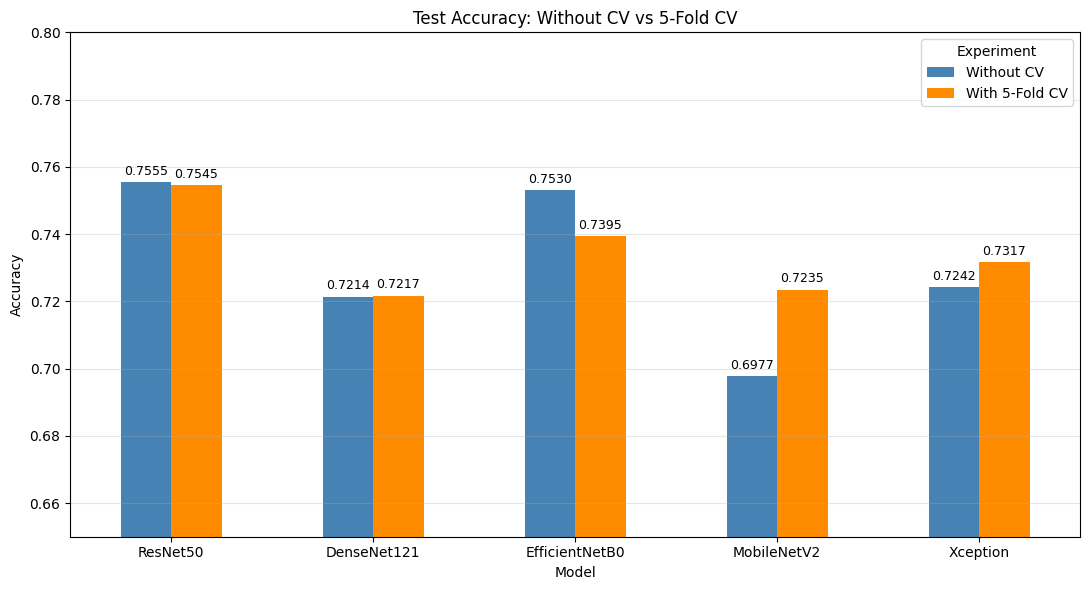

In [17]:
accuracy_pivot = all_results_df.pivot(
    index="Model",
    columns="Cross-Validation",
    values="Accuracy"
).reindex(model_order)

accuracy_pivot = accuracy_pivot[
    ["No", "5-Fold"]
]

accuracy_pivot.columns = [
    "Without CV",
    "With 5-Fold CV"
]

ax = accuracy_pivot.plot(
    kind="bar",
    figsize=(11, 6),
    color=[
        "steelblue",
        "darkorange"
    ]
)

plt.title(
    "Test Accuracy: Without CV vs 5-Fold CV"
)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.65, 0.80)
plt.xticks(rotation=0)
plt.legend(title="Experiment")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

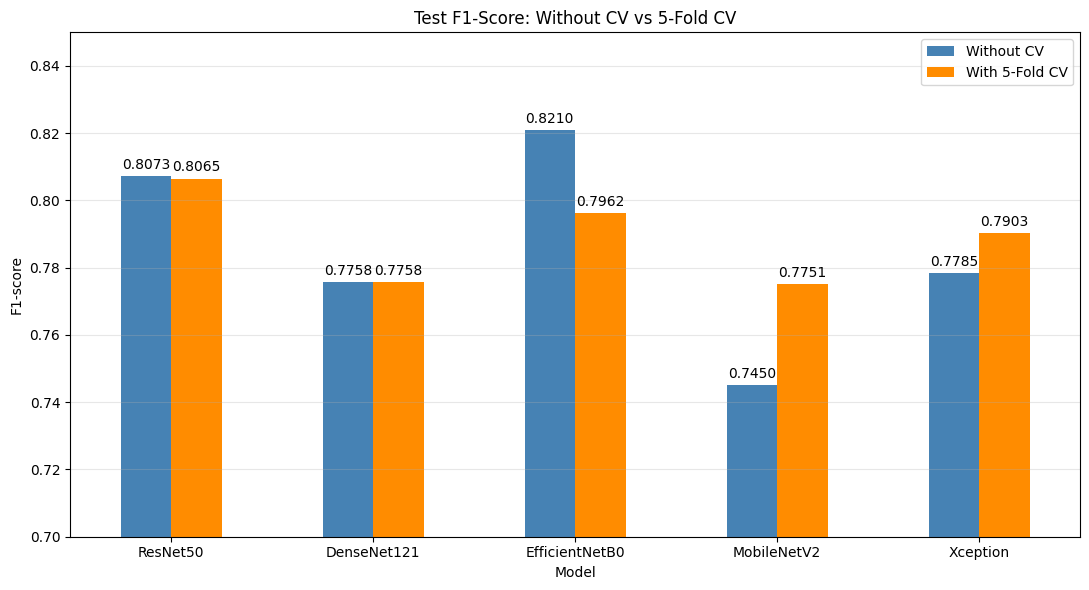

In [18]:
f1_pivot = (
    all_results_df
    .pivot(index="Model", columns="Cross-Validation", values="F1-score")
    .reindex(model_order)
)

f1_pivot = f1_pivot[["No", "5-Fold"]]
f1_pivot.columns = ["Without CV", "With 5-Fold CV"]

ax = f1_pivot.plot(
    kind="bar",
    figsize=(11, 6),
    color=["steelblue", "darkorange"]
)

plt.title("Test F1-Score: Without CV vs 5-Fold CV")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0.70, 0.85)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.tight_layout()
plt.show()

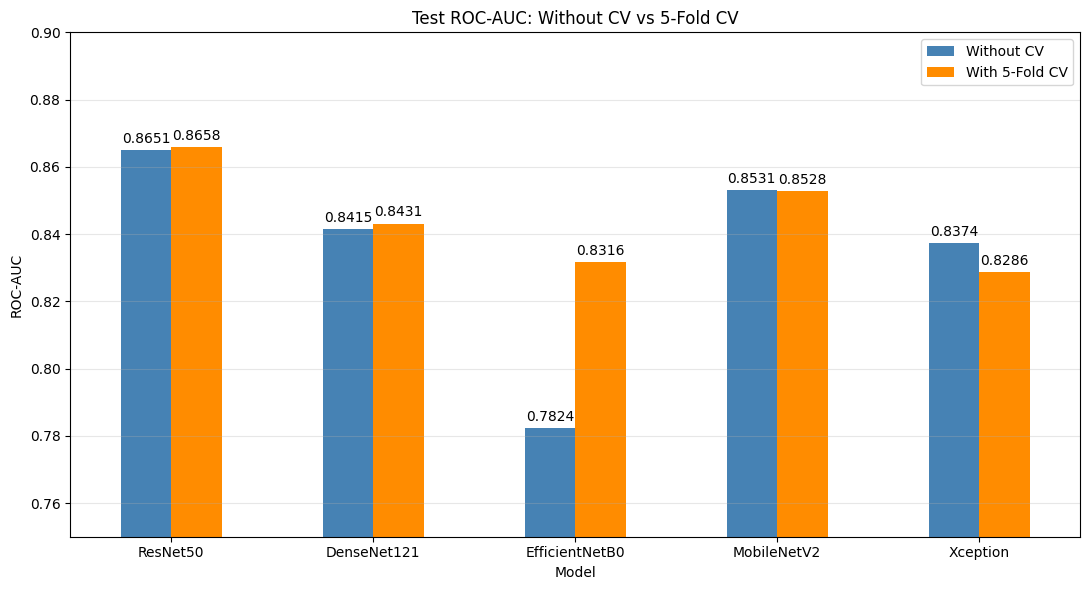

In [19]:
auc_pivot = (
    all_results_df
    .pivot(index="Model", columns="Cross-Validation", values="ROC-AUC")
    .reindex(model_order)
)

auc_pivot = auc_pivot[["No", "5-Fold"]]
auc_pivot.columns = ["Without CV", "With 5-Fold CV"]

ax = auc_pivot.plot(
    kind="bar",
    figsize=(11, 6),
    color=["steelblue", "darkorange"]
)

plt.title("Test ROC-AUC: Without CV vs 5-Fold CV")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0.75, 0.90)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.tight_layout()
plt.show()

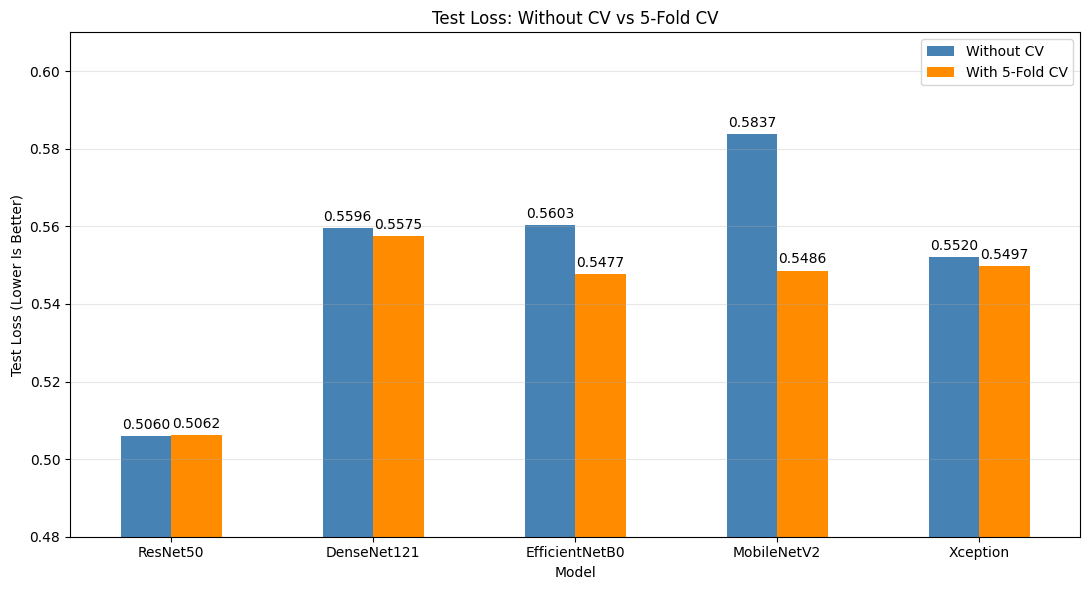

In [20]:
loss_pivot = (
    all_results_df
    .pivot(index="Model", columns="Cross-Validation", values="Test Loss")
    .reindex(model_order)
)

loss_pivot = loss_pivot[["No", "5-Fold"]]
loss_pivot.columns = ["Without CV", "With 5-Fold CV"]

ax = loss_pivot.plot(
    kind="bar",
    figsize=(11, 6),
    color=["steelblue", "darkorange"]
)

plt.title("Test Loss: Without CV vs 5-Fold CV")
plt.xlabel("Model")
plt.ylabel("Test Loss (Lower Is Better)")
plt.ylim(0.48, 0.61)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.tight_layout()
plt.show()

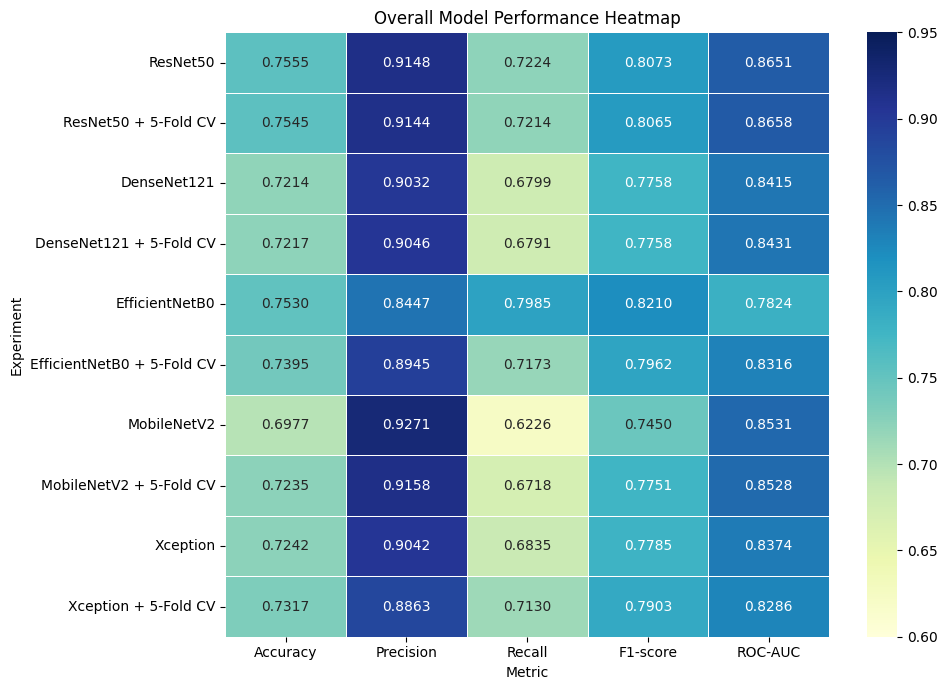

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = all_results_df.set_index("Experiment")[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    linewidths=0.5,
    vmin=0.60,
    vmax=0.95
)

plt.title("Overall Model Performance Heatmap")
plt.xlabel("Metric")
plt.ylabel("Experiment")
plt.tight_layout()
plt.show()

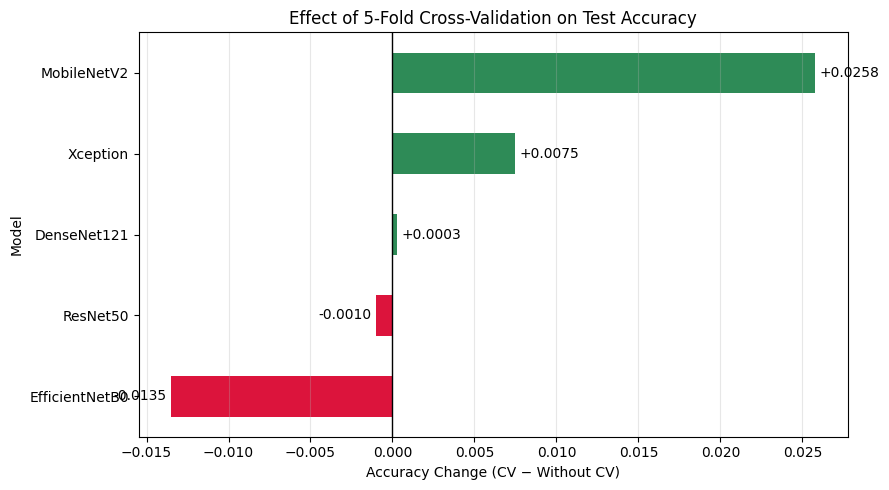

In [22]:
cv_effect = accuracy_pivot.copy()
cv_effect["Accuracy Change"] = (
    cv_effect["With 5-Fold CV"] - cv_effect["Without CV"]
)

cv_effect = cv_effect.sort_values("Accuracy Change")

colors = [
    "seagreen" if value > 0 else "crimson"
    for value in cv_effect["Accuracy Change"]
]

ax = cv_effect["Accuracy Change"].plot(
    kind="barh",
    figsize=(9, 5),
    color=colors
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Effect of 5-Fold Cross-Validation on Test Accuracy")
plt.xlabel("Accuracy Change (CV − Without CV)")
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%+.4f", padding=3)

plt.tight_layout()
plt.show()